# phase1: data reorganizing

In [ ]:
import pandas as pd
import os
import shutil

# variable definition and path joining 
INPUT_ROOT = '/kaggle/input/finger-dataset/Finger dataset'
TRAIN_SRC = os.path.join(INPUT_ROOT, 'train_finger_only/XR_FINGER')
VALID_SRC = os.path.join(INPUT_ROOT, 'valid_finger_only/XR_FINGER')


OUTPUT_DIR = '/kaggle/working/processed_finger_data'

TARGET_DIRS = {
    'train_0': os.path.join(OUTPUT_DIR, 'train/0_NEGATIVE'),
    'train_1': os.path.join(OUTPUT_DIR, 'train/1_POSITIVE'),
    'valid_0': os.path.join(OUTPUT_DIR, 'valid/0_NEGATIVE'),
    'valid_1': os.path.join(OUTPUT_DIR, 'valid/1_POSITIVE')
}

def create_dirs():
    for path in TARGET_DIRS.values():
        os.makedirs(path, exist_ok=True)
    print(" Destination folders created in /kaggle/working/")

def reorganize_by_labels(source_root, mode='train'):
    count = 0
    # Patient folders (e.g., patient11191) ke andar scan karna
    for patient_folder in os.listdir(source_root):
        patient_path = os.path.join(source_root, patient_folder)
        
        if os.path.isdir(patient_path):
            # Har patient ke andar study folders hote hain (study1_positive, etc.)
            for study_folder in os.listdir(patient_path):
                study_path = os.path.join(patient_path, study_folder)
                
                # Label nikalna: Agar folder name mein 'positive' hai to 1, warna 0
                label = '1' if 'positive' in study_folder.lower() else '0'
                target_dir = TARGET_DIRS[f'{mode}_{label}']
                
                # Study folder ke andar images (image1.png, etc.) copy karna
                for img_file in os.listdir(study_path):
                    if img_file.endswith('.png'):
                        src_img_path = os.path.join(study_path, img_file)
                        # Unique name banayein taake overlap na ho
                        new_name = f"{patient_folder}_{study_folder}_{img_file}"
                        dest_img_path = os.path.join(target_dir, new_name)
                        
                        shutil.copy(src_img_path, dest_img_path)
                        count += 1
    return count

# Execution
create_dirs()
print("Moving images into Class-based folders")

t_count = reorganize_by_labels(TRAIN_SRC, 'train')
v_count = reorganize_by_labels(VALID_SRC, 'valid')

print("-" * 30)
print(f" Done! Training Images: {t_count}")
print(f" Done! Validation Images: {v_count}")
print(f" Data ready at: {OUTPUT_DIR}")

In [ ]:
import os

base_path = '/kaggle/working/processed_finger_data'
for split in ['train', 'valid']:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        print(f" Folder: {split}")
        for label in os.listdir(split_path):
            label_path = os.path.join(split_path, label)
            file_count = len(os.listdir(label_path))
            print(f"   {label}: {file_count} images")

📁 Folder: train
   └── 🏷️ 1_POSITIVE: 1968 images
   └── 🏷️ 0_NEGATIVE: 3138 images
📁 Folder: valid
   └── 🏷️ 1_POSITIVE: 247 images
   └── 🏷️ 0_NEGATIVE: 214 images


# Phase 2: CNN Training (DenseNet121 Classifier)

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# --- 1. Data Generators (Soft Augmentation Applied) ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,       # Reduced for bone clarity
    width_shift_range=0.05, 
    height_shift_range=0.05,
    zoom_range=0.05,        # Keeps bone within frame
    horizontal_flip=True,
    fill_mode='constant',   # Cleaner borders for X-rays
    cval=0 
)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    '/kaggle/working/processed_finger_data/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)
valid_gen = valid_datagen.flow_from_directory(
    '/kaggle/working/processed_finger_data/valid',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

# --- 2. Build Model (Full Unfreezing) ---
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# IMPROVEMENT: Unfreeze the entire model to learn finger anatomy from scratch
base_model.trainable = True 

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Feature Layer Bridge
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
feature_layer = Dense(512, activation='relu', name="feature_output")(x) 
x = Dropout(0.3)(feature_layer)

predictions = Dense(1, activation='sigmoid')(x)
cnn_model = Model(inputs=base_model.input, outputs=predictions)

# --- 3. Updated Scheduler Logic ---
def lr_scheduler_fn(epoch, lr):
    # Gradual decay taake convergence stable rahe
    if epoch < 10:
        return float(lr) 
    else:
        new_lr = lr * tf.math.exp(-0.05)
        return float(new_lr)

# --- 4. Callbacks & Weights ---
from sklearn.utils import class_weight
labels = train_gen.classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = {0: float(weights[0]), 1: float(weights[1] * 1.2)}

early_stop = EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max')
checkpoint = ModelCheckpoint('best_cnn_features.keras', monitor='val_auc', save_best_only=True, mode='max')
lr_schedule = LearningRateScheduler(lr_scheduler_fn, verbose=1)

# --- 5. Compile & Train (Higher Learning Rate) ---
# IMPROVEMENT: Increased LR to 1e-4 so the model actually starts learning
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f" Balanced Class Weights: {class_weight_dict}")
print(" Re-training with Full Model Unfreezing and Soft Augmentation...")

history = cnn_model.fit(
    train_gen, 
    validation_data=valid_gen, 
    epochs=50, 
    class_weight=class_weight_dict,
    callbacks=[checkpoint, lr_schedule, early_stop]
)

2026-01-25 04:33:41.218299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769315621.411801      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769315621.466649      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769315621.925188      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769315621.925241      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769315621.925244      55 computation_placer.cc:177] computation placer alr

Found 5106 images belonging to 2 classes.
Found 461 images belonging to 2 classes.


I0000 00:00:1769315634.801307      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Balanced Class Weights: {0: 0.8135755258126195, 1: 1.556707317073171}
 Re-training with Full Model Unfreezing and Soft Augmentation...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/50


I0000 00:00:1769315694.436115     156 service.cc:152] XLA service 0x7a0b74002140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769315694.436157     156 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769315704.755800     156 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/320 ━━━━━━━━━━━━━━━━━━━━ 14:00:50 158s/step - accuracy: 0.6250 - auc: 0.5641 - loss: 0.6508

I0000 00:00:1769315796.995029     156 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


320/320 ━━━━━━━━━━━━━━━━━━━━ 371s 668ms/step - accuracy: 0.6253 - auc: 0.6743 - loss: 0.7973 - val_accuracy: 0.6920 - val_auc: 0.7471 - val_loss: 0.6749 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 63s 196ms/step - accuracy: 0.6782 - auc: 0.7542 - loss: 0.7115 - val_accuracy: 0.6464 - val_auc: 0.7151 - val_loss: 0.7101 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 66s 206ms/step - accuracy: 0.7301 - auc: 0.8106 - loss: 0.6117 - val_accuracy: 0.7158 - val_auc: 0.7949 - val_loss: 0.6391 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 64s 200ms/step - accuracy: 0.7353 - auc: 0.8267 - loss: 0.5842 - val_accuracy: 0.7462 - val_auc: 0.8309 - val_loss: 0.5690 - learning_rate: 1.0000e-04

Epoch

# Data Augmentation

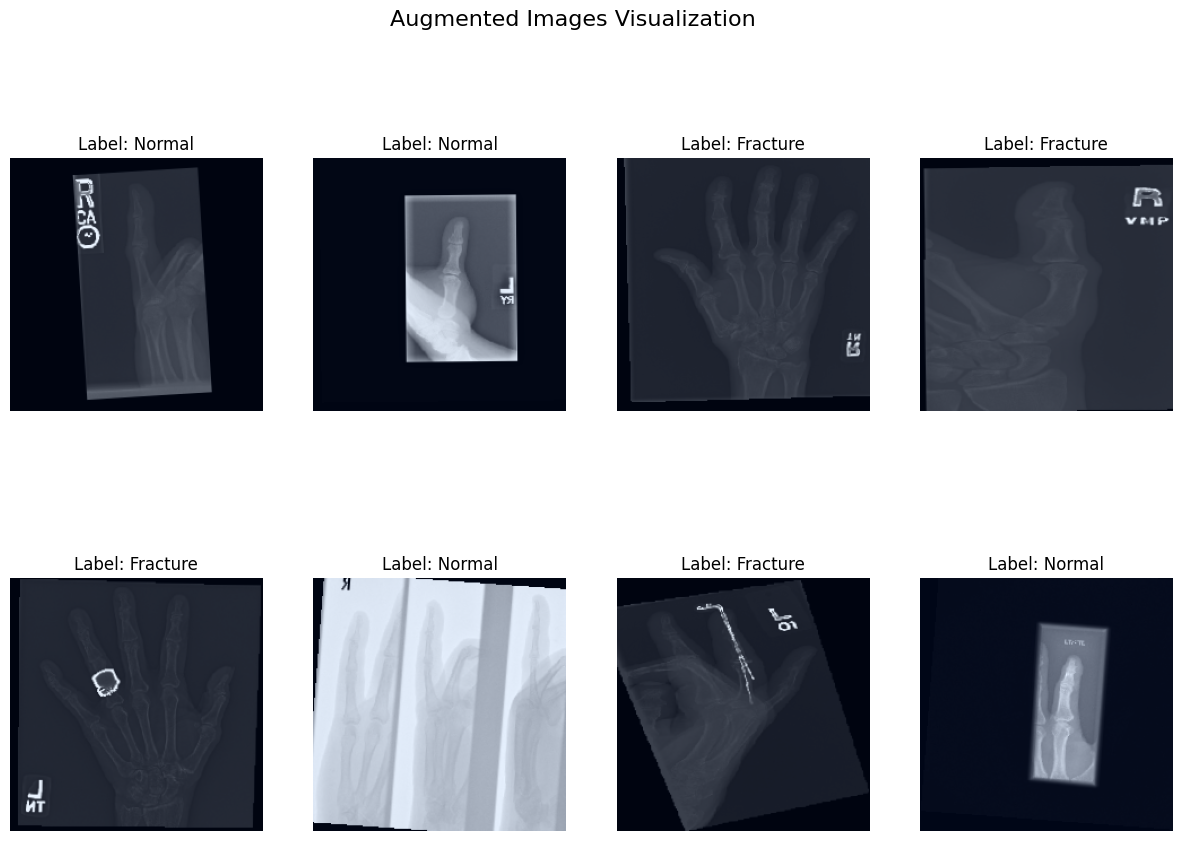

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_gen)

plt.figure(figsize=(15, 10))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min()) 
    
    plt.imshow(img)
    label_text = "Fracture" if labels[i] == 1 else "Normal"
    plt.title(f"Label: {label_text}")
    plt.axis('off')

plt.suptitle("Augmented Images Visualization", fontsize=16)
plt.show()

# Confusion Matrix

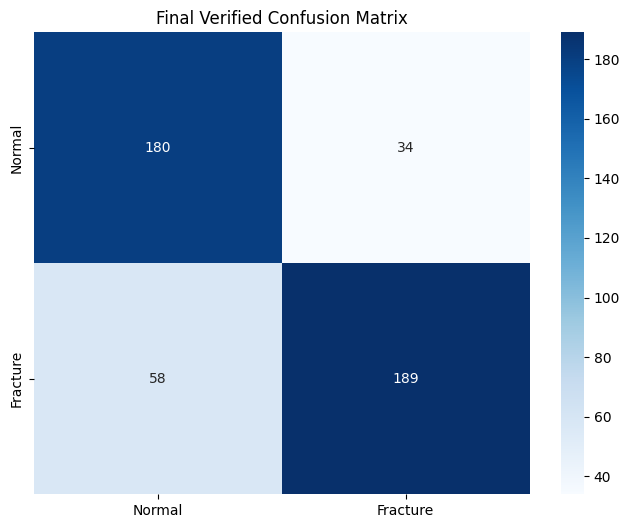

📊 Verified Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.84      0.80       214
    Fracture       0.85      0.77      0.80       247

    accuracy                           0.80       461
   macro avg       0.80      0.80      0.80       461
weighted avg       0.81      0.80      0.80       461



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

valid_gen.reset()
valid_gen.shuffle = False

y_true = []
y_pred_probs = []

for i in range(len(valid_gen)):
    X, y = valid_gen[i]
    y_true.extend(y)
    preds = cnn_model.predict(X, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int).flatten()

#  Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fracture'], 
            yticklabels=['Normal', 'Fracture'])
plt.title('Final Verified Confusion Matrix')
plt.show()

#  Final Report
print("📊 Verified Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fracture']))

# Phase 3: Text Preparation & Tokenization

In [ ]:
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

# In 14 reports ko Tokenizer aur Generator dono use karenge
global train_reports_positive, train_reports_negative
train_reports_positive = [
    "<start> acute fracture identified in the finger bone <end>",
    "<start> evidence of cortical break consistent with fracture <end>",
    "<start> positive study for traumatic bone injury <end>",
    "<start> clear disruption of bone cortex observed in the finger digit <end>",
    "<start> oblique fracture line visualized within the phalangeal structure <end>",
    "<start> displaced bone fragment noted indicating an acute fracture <end>",
    "<start> focal bony abnormality suggestive of a recent traumatic fracture <end>"
]

train_reports_negative = [
    "<start> the finger study is normal no fracture <end>",
    "<start> no evidence of acute fracture or dislocation <end>",
    "<start> unremarkable study of the finger digit <end>",
    "<start> bone alignment and cortical margins appear fully intact <end>",
    "<start> no radiographic evidence of acute bony injury detected <end>",
    "<start> soft tissues and joints appear normal with no fracture <end>",
    "<start> study demonstrates preserved joint spaces and no bone breakage <end>"
]

#  Tokenizer Setup
all_reports = train_reports_positive + train_reports_negative
tokenizer = Tokenizer(filters='!"#$%&()*+,-./:;?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(all_reports)

#  Save Tokenizer (UI deployment ke liye zaroori hai)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

#  Global Variables Update
# In variables ko RNN Training (Phase 5.2) direct use karegi
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(r.split()) for r in all_reports) 

print(f" Phase 3 Updated: Tokenizer and Reports are now globally synced!")
print(f"   Vocab Size: {vocab_size} | Max Length: {max_length}")

✅ Phase 3 Updated: Tokenizer and Reports are now globally synced!
   Vocab Size: 65 | Max Length: 12


# phase 4: Feature Extraction For RNN and SMOTE

In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications.densenet import preprocess_input

# CNN se sahi layer 'feature_output' uthana
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer("feature_output").output)

def get_accurate_features(directory):
    features = {}
    categories = ['0_NEGATIVE', '1_POSITIVE']
    print(" Extracting 512-D Features from CNN...")
    for label in categories:
        path = os.path.join(directory, label)
        if not os.path.exists(path): continue
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))
            
            feature = feature_extractor.predict(img_preprocessed, verbose=0)
            # Label ko key mein rakhna zaroori hai
            features[f"{label}_{img_name}"] = feature.flatten()
    print(f" Extracted {len(features)} features.")
    return features

train_features_final = get_accurate_features('/kaggle/working/processed_finger_data/train')

⌛ Extracting 512-D Features from CNN...
✅ Extracted 5106 features.


# SMOTE Data Balancing Technique 

In [ ]:
import numpy as np
from imblearn.over_sampling import SMOTE

#  Dictionary se Data Arrays mein convert karna
X = np.array(list(train_features_final.values()))
y = np.array([1 if '1_POSITIVE' in k else 0 for k in train_features_final.keys()])

print(f" Before SMOTE: Normal = {np.bincount(y)[0]}, Fracture = {np.bincount(y)[1]}")

# smote
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print(f" After SMOTE: Normal = {np.bincount(y_resampled)[0]}, Fracture = {np.bincount(y_resampled)[1]}")

#  Final Balanced Features Dictionary
balanced_features = {} # Yeh naam hum RNN training ke liye use karenge
for i in range(len(X_resampled)):
    label_str = '1_POSITIVE' if y_resampled[i] == 1 else '0_NEGATIVE'
    img_key = f"img_{i}_{label_str}"
    balanced_features[img_key] = X_resampled[i]

print(" Success: 'balanced_features' ab fully balanced hain aur ready hain!")

📊 Before SMOTE: Normal = 3138, Fracture = 1968
✅ After SMOTE: Normal = 3138, Fracture = 3138
🚀 Success: 'balanced_features' ab fully balanced hain aur ready hain!


# phase 5.2: Data Generator aur Training(RNN)

In [ ]:
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model

def data_generator_v4(features, tokenizer, max_length, batch_size):
    X1, X2, y = [], [], []
    img_keys = list(features.keys())
    while True:
        random.shuffle(img_keys)
        for key in img_keys:
            feature = features[key]
        
            report = random.choice(train_reports_positive) if '1_POSITIVE' in key else random.choice(train_reports_negative)
            
            seq = tokenizer.texts_to_sequences([report])[0]
            for i in range(1, len(seq)):
                in_seq = pad_sequences([seq[:i]], maxlen=max_length, padding='post')[0]
                out_seq = seq[i]
                
                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)
                
                if len(X1) == batch_size:
                    yield ((np.array(X1), np.array(X2)), np.array(y))
                    X1, X2, y = [], [], []

# --- RNN Architecture Setup ---
try:
    print(f"📊 Current Vocab Size: {vocab_size}")
    print(f"📊 Current Max Length: {max_length}")

    # Image Input (512-D features from CNN)
    image_input = Input(shape=(512,), name="image_input")
    fe1 = Dropout(0.5)(image_input)
    fe2 = Dense(256, activation='relu')(fe1)

    # Text Sequence Input
    text_input = Input(shape=(max_length,), name="text_input")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(text_input) 
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    # Merge Vision and Language
    decoder1 = Add()([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    caption_model = Model(inputs=[image_input, text_input], outputs=outputs)
    caption_model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))

    # --- Execution & Training ---
    # Phase 4 se extracted features 'balanced_features' check
    if 'balanced_features' in locals() or 'balanced_features' in globals():
        print(f"🚀 Training starting on {len(balanced_features)} samples...")
        
        batch_size = 16
        steps = len(balanced_features) // batch_size
        
        history = caption_model.fit(
            data_generator_v4(balanced_features, tokenizer, max_length, batch_size),
            steps_per_epoch=steps,
            epochs=65, 
            verbose=1
        )

        caption_model.save('final_finger_report_model.keras')
        print(" Success: RNN Model saved as 'final_finger_report_model.keras'")
    else:
        print(" Error: 'balanced_features' nahi milay. Pehle Phase 4 (Feature Extraction) run karein.")

except NameError as e:
    print(f" Critical Error: {e}. Please ensure Phase 3 (Tokenizer & Reports) is executed before this cell.")

📊 Current Vocab Size: 65
📊 Current Max Length: 12
🚀 Training starting on 6276 samples...
Epoch 1/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 4.1070
Epoch 2/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.3118
Epoch 3/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.8991
Epoch 4/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.3813
Epoch 5/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9606
Epoch 6/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6100
Epoch 7/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3139
Epoch 8/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.1012
Epoch 9/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.9140
Epoch 10/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7572
Epoch 11/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6353
Epoch 12/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5048
Epoch 13/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4433
Epoch 14/65
392/392 ━━━━━━━━━━━━━━━━

In [28]:
import os
import random

def get_random_test_image(base_dir='/kaggle/working/processed_finger_data/val'):
    categories = ['0_NEGATIVE', '1_POSITIVE']
    # Randomly ek category select karein
    category = random.choice(categories)
    cat_path = os.path.join(base_dir, category)
    
    if os.path.exists(cat_path):
        images = os.listdir(cat_path)
        if images:
            random_img = random.choice(images)
            full_path = os.path.join(cat_path, random_img)
            return full_path, category
    return None, None

In [ ]:
import os
# Check karein ke ye folder exist karta hai ya nahi
print(os.listdir('/kaggle/working/'))

In [ ]:
import os
import random

def get_random_test_image():
    # 1. Base directory setup
    base_dir = '/kaggle/working/processed_finger_data/val'
    
    # Check karein agar path mojood hai
    if not os.path.exists(base_dir):
        # Agar folder ka naam different ho sakta hai toh search karein
        print("🔍 Searching for validation folder...")
        for root, dirs, files in os.walk('/kaggle/working/'):
            if 'val' in dirs:
                base_dir = os.path.join(root, 'val')
                print(f" Found path: {base_dir}")
                break
    
    if not os.path.exists(base_dir):
        print(" Error: Validation folder nahi mila. 'processed_finger_data' check karein.")
        return None, None

    # 2. Categories check karein
    categories = ['0_NEGATIVE', '1_POSITIVE']
    random.shuffle(categories)
    
    for category in categories:
        cat_path = os.path.join(base_dir, category)
        if os.path.exists(cat_path):
            images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if images:
                img_name = random.choice(images)
                full_path = os.path.join(cat_path, img_name)
                print(f" Selected Image: {img_name} from {category}")
                return full_path, category
                
    return None, None

# Ab check karein
path, label = get_random_test_image()

🔍 Searching for validation folder...
❌ Error: Validation folder nahi mila. 'processed_finger_data' check karein.


# phase 6 : report generation (testing phase)

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.densenet import preprocess_input

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

#  Image Selection (Random from Validation Set) 
def get_random_test_image():
    base_dir = '/kaggle/working/processed_finger_data/valid'
    if not os.path.exists(base_dir):
        return None, None
    categories = ['0_NEGATIVE', '1_POSITIVE']
    category = random.choice(categories)
    cat_path = os.path.join(base_dir, category)
    if os.path.exists(cat_path):
        images = [img for img in os.listdir(cat_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            return os.path.join(cat_path, random.choice(images)), category
    return None, None

#  Main Medical Prediction Function 
def generate_medical_result(img_path, classification_model, feature_model, caption_model, tokenizer, max_length=12):
    # Image loading
    raw_img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(raw_img)
    img_for_pred = preprocess_input(np.expand_dims(img_array.copy(), axis=0))
    
    # Diagnosis (CNN Classification)
    diagnosis_prob = classification_model.predict(img_for_pred, verbose=0)[0][0]
    diagnosis = "FRACTURE DETECTED" if diagnosis_prob > 0.5 else "NO FRACTURE (Normal)"
    color = 'red' if diagnosis_prob > 0.5 else 'green'

    # Feature Extraction (CNN to Vector)
    feature = feature_model.predict(img_for_pred, verbose=0).reshape(1, 512)

    # Report Generation Loop (Autoregressive)
    in_text = 'start'
    
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        
        # Tensors mein convert karke direct call (Bypass cuDNN Assertion)
        feat_tensor = tf.convert_to_tensor(feature, dtype=tf.float32)
        seq_tensor = tf.convert_to_tensor(sequence, dtype=tf.float32)
        
        predictions = caption_model([feat_tensor, seq_tensor], training=False)
        
        yhat = np.argmax(predictions.numpy())
        word = word_for_id(yhat, tokenizer)
        
        if word is None or word == 'end':
            break
        in_text += ' ' + word
        
    final_report = in_text.replace('start', '').replace('end', '').strip()
    
    # Har tarah ke special symbols aur extra brackets saaf karein
    chars_to_remove = ["<", ">", "[", "]", "{", "}"]
    for char in chars_to_remove:
        final_report = final_report.replace(char, "")
    
    # Extra spaces khatam karke sentence format mein layein
    final_report = " ".join(final_report.split()).capitalize()
    if not final_report.endswith('.'):
        final_report += "."
    
    #  Display Results 
    plt.figure(figsize=(7, 7))
    plt.imshow(img_array.astype('uint8'))
    title_text = f"DIAGNOSIS: {diagnosis}\nAI REPORT: {final_report}"
    plt.title(title_text, fontsize=12, color=color, fontweight='bold', pad=20)
    plt.axis('off')
    plt.show()

    print(f" CNN Confidence: {diagnosis_prob:.4f}")
    print(f" Final Cleaned Report: {final_report}")

#  Execution 
path, label = get_random_test_image()
if path:
    print(f" Image Selected: {os.path.basename(path)}")
    generate_medical_result(path, cnn_model, feature_extractor, caption_model, tokenizer, max_length=12)

2026-03-07 17:33:21.362074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772904801.585856      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772904801.649180      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772904802.151031      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772904802.151079      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772904802.151082      55 computation_placer.cc:177] computation placer alr

In [ ]:
# Validation set se features nikalne ke liye
valid_features_final = get_accurate_features('/kaggle/working/processed_finger_data/valid')

print(f" Success: {len(valid_features_final)} validation features extracted and saved in 'valid_features_final'.")

⌛ Extracting 512-D Features from CNN...
✅ Extracted 461 features.
✅ Success: 461 validation features extracted and saved in 'valid_features_final'.


# Phase 7: Model Evaluation (BLEU Score & Graphs)

⌛ Calculating BLEU scores on Validation Set (Using CPU/Direct Call)...

 Final Results:
 BLEU-1 Score: 16.20%
 BLEU-2 Score: 11.72%


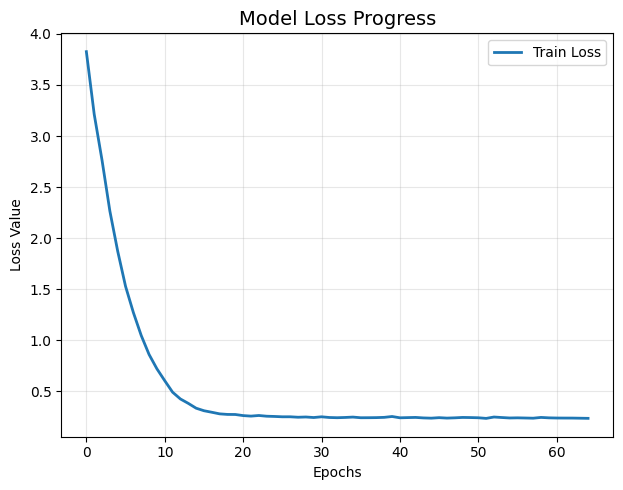

In [ ]:
import numpy as np
import tensorflow as tf
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

#  BLEU Score Calculation (Direct Call Version) 
def calculate_metrics(features, tokenizer, caption_model, max_length=12):
    actual, predicted = [], []
    
    print(" Calculating BLEU scores on Validation Set (Using CPU/Direct Call)...")
    
    for key, feature in features.items():
        if '1_POSITIVE' in key:
            target = "acute fracture identified in the finger bone"
        else:
            target = "no evidence of acute fracture or dislocation"
            
        in_text = 'start'
        feature_reshaped = feature.reshape(1, 512)
        
        with tf.device('/cpu:0'):
            for i in range(max_length):
                sequence = tokenizer.texts_to_sequences([in_text])[0]
                sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
                
                feat_tensor = tf.convert_to_tensor(feature_reshaped, dtype=tf.float32)
                seq_tensor = tf.convert_to_tensor(sequence, dtype=tf.float32)
                
                preds = caption_model([feat_tensor, seq_tensor], training=False)
                yhat = np.argmax(preds.numpy())
                word = word_for_id(yhat, tokenizer)
                
                if word is None or word == 'end':
                    break
                in_text += ' ' + word
        
        cleaned_pred = in_text.replace('start', '').replace('end', '').strip()
        
        actual.append([target.split()])
        predicted.append(cleaned_pred.split())

    bleu1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
    
    print(f"\n Final Results:")
    print(f" BLEU-1 Score: {bleu1*100:.2f}%")
    print(f" BLEU-2 Score: {bleu2*100:.2f}%")
    return bleu1, bleu2

def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
    plt.title('Model Loss Progress', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Agar accuracy mojud ho (optional for CNN)
    if 'accuracy' in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Train Acc', color='#2ca02c', linewidth=2)
        if 'val_accuracy' in history.history:
            plt.plot(history.history['val_accuracy'], label='Val Acc', color='#d62728', linewidth=2)
        plt.title('Model Accuracy Progress', fontsize=14)
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

#  Execute Evaluation 
# Sab se pehle validation set ke features extract karein (agar memory mein nahi hain)
# valid_features = get_accurate_features('/kaggle/working/processed_finger_data/valid')

# Metrics calculate karein
bleu1, bleu2 = calculate_metrics(valid_features_final, tokenizer, caption_model)

# History plot (RNN ki history dikhane ke liye)
try:
    plot_training_history(history)
except NameError:
    print(" History variable not found in memory. Plotting skipped.")

In [ ]:
import pandas as pd
from IPython.display import display

def run_qualitative_analysis(num_samples=5):
    results = []
    
    for _ in range(num_samples):
        #  Random Image Pick karein
        path, actual_label = get_random_test_image()
        if not path: continue
        
        # Image Preprocessing
        raw_img = tf.keras.preprocessing.image.load_img(path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(raw_img)
        img_for_pred = preprocess_input(np.expand_dims(img_array.copy(), axis=0))
        
        # CNN Diagnosis
        diag_prob = cnn_model.predict(img_for_pred, verbose=0)[0][0]
        cnn_diag = "Positive" if diag_prob > 0.5 else "Negative"
        
        # RNN Report Generation (Direct Call Method)
        feature = feature_extractor.predict(img_for_pred, verbose=0).reshape(1, 512)
        in_text = 'start'
        with tf.device('/cpu:0'):
            for i in range(12):
                sequence = tokenizer.texts_to_sequences([in_text])[0]
                sequence = pad_sequences([sequence], maxlen=12, padding='post')
                preds = caption_model([tf.convert_to_tensor(feature), tf.convert_to_tensor(sequence)], training=False)
                word = word_for_id(np.argmax(preds.numpy()), tokenizer)
                if word is None or word == 'end': break
                in_text += ' ' + word
        
        # Data Clean-up
        clean_report = in_text.replace('start', '').replace('end', '').strip().capitalize()
        
        # Results Store karein
        results.append({
            "Image Name": os.path.basename(path),
            "Actual Class": actual_label,
            "CNN Prediction": f"{cnn_diag} ({diag_prob:.2f})",
            "AI Generated Report": clean_report
        })
    
    # Table Display
    df = pd.DataFrame(results)
    display(df)

# Run karein
run_qualitative_analysis(5)

,Image Name,Actual Class,CNN Prediction,AI Generated Report
0,patient11922_study1_negative_image1.png,0_NEGATIVE,Negative (0.00),No no evidence of acute fracture or dislocatio...
1,patient11935_study2_negative_image3.png,0_NEGATIVE,Negative (0.12),No evidence of acute fracture or dislocation <...
2,patient11300_study2_negative_image2.png,0_NEGATIVE,Negative (0.00),Bone alignment and cortical margins appear ful...
3,patient11888_study1_positive_image2.png,1_POSITIVE,Positive (1.00),Focal focal bony abnormality suggestive of a r...
4,patient11739_study1_negative_image2.png,0_NEGATIVE,Positive (0.64),Focal bony bony abnormality suggestive of a re...


In [25]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d0f97550cf64e30c1d8d8d2ac02923197cc4ff57d6906b8280fc9dc1ef1dff1c
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
